We will start by rewriting the whole ML cycle for the same dataset, using the exact same model and concept as '03-Makemore_MLP'

In [4]:
import torch, torch.nn.functional as F, matplotlib.pyplot as plt
import random

#Loading data and setting up data split

words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

print(f"Characters: \n",chars)
print(f"integer to string: \n",itos)
print(f"String to integer: \n",stoi)

random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)

train_words = words[:n1]
val_words = words[n1:n2]
test_words=words[n2:]

def build_dataset(words):

    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)

    return X,Y

Xtr,Ytr = build_dataset(train_words)
Xval,Yval = build_dataset(val_words)
Xtest,Ytest = build_dataset(test_words)


print(f"\nX training Shape:",Xtr.shape)
print(f" \nX Validation Shape:", Xval.shape)
print(f" \nX Test Shape:", Xtest.shape)


#Building MLP and setting up the training loop
torch.manual_seed(2147483647)
num_iterations = 15000
learning_rate = 0.01
n_hidden1 = 300
n_hidden2 = 27
n_embedding = 10
block_size = 3


C=torch.randn((27,n_embedding), requires_grad=True)
emb = C[Xtr]
x = emb.view(-1, n_embedding * block_size)


W1=torch.randn(n_embedding * block_size, n_hidden1, requires_grad=True)
b1=torch.randn(n_hidden1, requires_grad=True)


W2 = torch.randn(n_hidden1, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)
    h_b = torch.tanh(x @ W1 + b1)
    logits = h_b @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

#Evaluating trained model on validation data - compare with final training loss

#Forward Pass on validation data
emb = C[Xval]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(f"\nValidation Loss:",mean_neg_log.item())


#Forward Pass on training data - final training loss
emb = C[Xtr]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(f"\nFinal Training Loss:",mean_neg_log.item())




Characters: 
 ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
integer to string: 
 {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
String to integer: 
 {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}

X training Shape: torch.Size([182625, 3])
 
X Validation Shape: torch.Size([22655, 3])
 
X Test Shape: torch.Size([22866, 3])
(0, 3.3115203380584717)
(1, 3.1572535037994385)
(2, 3.1755430698394775)
(3, 3.0994906425476074)
(4, 3.0877959728240967)
(5, 3.040327787399292)
(6, 2.8415796756744385)
(7, 3.14009952545166)
(8, 2.7845394611358643)
(9, 2

One issue that was quietly lurking is the 'saturated tanh' issue, lets break this down step-by-step. When we conduct a backward pass, we start at the loss and propogate backwards through all of the neurons. Particularly, we will go through the tanh activation function which is present at every neuron ('h=torch.tanh(x @ W1 + b1)'). When we propogate the loss backwards through the network, we want to understand 'how much of an impact does changing the weights/bias actually have on the loss', so, what is the derivative of the specific neuron with repsect to the loss. We calculate this through the chain rule, for the tanh function this ends up being:
gradient (wrt to loss) = (1-t^2)* out gradient . Where t=tanh(x). The issue here is: If t = (1 or -1) the gradient wrt to loss ends up being 0 always. Essentially this means: That specific neuron cant be tuned. If you have a large number of these 'saturated tanh', you lose a large number of parameters since you can't tune them anymore.

Lets confirm this issue exists by looking at the table below

tensor([-0.8980, -0.1845,  1.0000,  0.9983,  0.9999,  0.9900, -0.1656, -0.9984,
         0.9869, -0.9999,  0.0794, -1.0000,  0.9974,  0.9998, -1.0000, -0.9464,
         1.0000, -0.9995, -1.0000,  0.9999,  1.0000,  0.0039,  0.9825, -0.9801,
        -1.0000, -1.0000,  0.9929, -1.0000, -0.9901, -0.9999, -0.9120, -0.9765,
        -1.0000, -1.0000,  0.8264, -0.9995, -0.6300, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -0.8944, -0.9489, -0.9914,  0.9997,  0.9978,  1.0000,
         0.7680,  0.9983, -1.0000,  0.9874, -0.5723, -0.9999,  1.0000, -0.9998,
         0.5786,  1.0000,  0.8144,  0.9523,  1.0000, -1.0000,  1.0000,  0.9997,
        -0.9938, -1.0000,  1.0000,  0.9999,  0.1802,  1.0000, -1.0000,  0.8825,
        -1.0000,  1.0000,  1.0000,  1.0000,  0.9904,  0.9999, -0.6538, -0.9999,
        -0.9900,  0.6089, -0.9953, -0.9992, -1.0000,  1.0000,  0.0567, -1.0000,
        -0.6088,  0.9994, -0.9752,  0.9976, -0.2790, -1.0000,  0.3191, -0.4747,
        -0.9999, -1.0000, -0.6347,  0.99

(array([18058180.,  1368918.,   796087.,   646781.,   520256.,   388818.,
          384387.,   437884.,   296512.,   273557.,   216702.,   223318.,
          220509.,   191455.,   263814.,   237236.,   265309.,   257006.,
          294052.,   232212.,   214971.,   172066.,   197475.,   170976.,
          271107.,   271353.,   208741.,   277705.,   144002.,   347178.,
          299260.,   215830.,   270854.,   171481.,   217568.,   287179.,
          219702.,   243731.,   257962.,   301750.,   255127.,   263465.,
          337996.,   368652.,   424261.,   524318.,   612874.,   924082.,
         1369221., 19373620.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,

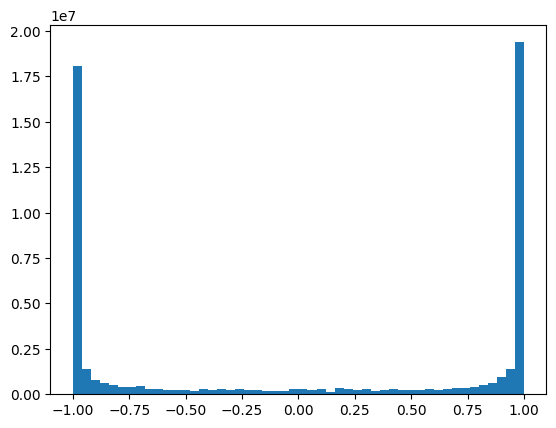

In [5]:
print(h[20])
plt.hist(h.view(-1).tolist(),50)

Notice how a large number is either -1 or 1, suggested that we have a lot of saturated tanh. An issue we have to solve. This histogram however is a bit deceptive. Lets track back a bit to understand why, remember, to get 'h' in the first place we went through this process:

C=torch.randn((27,n_embedding) -> C = (27,10)

W1=torch.randn(n_embedding * block_size, n_hidden1, requires_grad=True) -> w1 = (30,300)

Xtr = (182625,3)

emb = C[Xtr] -> emb = (182625,3,10)

x = emb.view(-1,n_embedding * block_size) -> x = (182625, 30)

h=torch.tanh(x @ W1 + b1) -> h = (182625, 30) @ (30,300) = (182625,300)


Intuitively, this means that for every one of the 182625 examples 'h' produce an 'activation' for each of the 300 neurons.

The above histogram 'plt.hist(h.view(-1).tolist(),50)' essentially flattens this list by displaying all of the '182625 * 300 = 54,787,500' activations all at once. In order to understand why this is deceptive we need to differentiate between a 'saturated tanh' and a completely 'dead neuron'. As displayed above we have 300 neurons, lets say for one of those 182625 examples we discovered that the tanh is saturated. This doesn't necessarily mean that neuron is useless. A neuron is only really 'dead' if the tanh is saturated for all of the 182625 examples.

The next step is to visualize the tanh saturation for each neuron across the 182625 examples to see if any neurons are 'dead' or if any neurons have a large number of saturated tanh's. The more saturated tanhs in a neuron, the less it can train

For visualization purposes, we will look at the graph for 'h_b', which is 'h' for a mini-batch of 32, rather than for the whole dataset

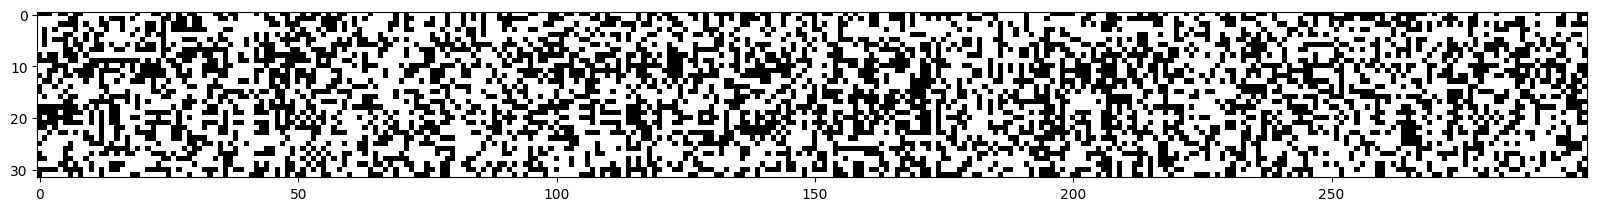

In [6]:
plt.figure(figsize=(20,10))
plt.imshow(h_b.abs() > 0.99, cmap='grey', interpolation='nearest')

If h_b.abs() > 0.99 is true the chart shows white. If its false it shows black. The large amount of white is consistent with the large number of saturated tanh which we previously determined. Although, visually, it doesn't seem like any neuron is fully dead. Regardless, we will still work on trying to improve this situation. Once again, lets take a step backwards. What results in 'h' = 1 ? Remember that h = tanh(z), where z = x @ W1 + b1. For h = +-1, z absolute value must be large (eg tanh(3)=0.995). Lets visualize the chart of z

(array([2.000000e+00, 4.140000e+02, 2.440000e+02, 6.270000e+02,
        1.042000e+03, 2.874000e+03, 4.802000e+03, 5.779000e+03,
        1.484500e+04, 2.428100e+04, 3.786400e+04, 6.089000e+04,
        1.091450e+05, 1.814370e+05, 3.274630e+05, 5.258370e+05,
        7.980150e+05, 1.231239e+06, 1.610871e+06, 2.021091e+06,
        2.725132e+06, 3.257382e+06, 3.698598e+06, 4.220669e+06,
        5.111459e+06, 5.571856e+06, 4.466417e+06, 3.854353e+06,
        3.487569e+06, 3.135354e+06, 2.491733e+06, 1.935087e+06,
        1.297812e+06, 9.013570e+05, 6.651160e+05, 4.140190e+05,
        2.708220e+05, 1.356500e+05, 8.510600e+04, 4.680800e+04,
        2.850800e+04, 1.480800e+04, 6.692000e+03, 3.046000e+03,
        1.693000e+03, 8.200000e+02, 6.880000e+02, 8.200000e+01,
        9.400000e+01, 8.000000e+00]),
 array([-27.82147026, -26.71324902, -25.60502777, -24.49680653,
        -23.38858528, -22.28036404, -21.17214279, -20.06392155,
        -18.9557003 , -17.84747906, -16.73925781, -15.63103657,
  

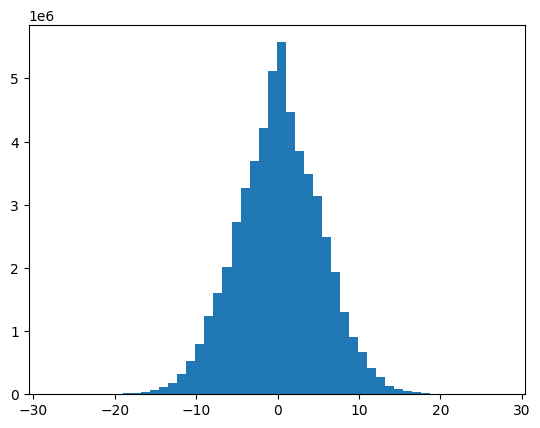

In [7]:
plt.hist(( x @ W1 + b1).view(-1).tolist(),50)

Notice how there are a lot of values which are big, this confirms our hypothesis. Hence, our next step is to reduce the size of the pre-activation (x @ W1 + b1), we can do this by scaling W1 and b1 down. Then, we will re-run the model and inspect the updated results

(0, 3.3064188957214355)
(1, 3.214510202407837)
(2, 3.215421438217163)
(3, 3.1527934074401855)
(4, 3.1450185775756836)
(5, 3.0853781700134277)
(6, 2.950294256210327)
(7, 3.1279280185699463)
(8, 2.9210567474365234)
(9, 2.9554696083068848)
(10, 2.8244388103485107)
(11, 2.7552220821380615)
(12, 2.625577926635742)
(13, 2.8571131229400635)
(14, 2.665849447250366)
(15, 2.9899494647979736)
(16, 2.793102502822876)
(17, 2.825167655944824)
(18, 2.6117196083068848)
(19, 2.751218795776367)
(20, 2.9538588523864746)
(21, 2.866077184677124)
(22, 2.693871021270752)
(23, 2.7121658325195312)
(24, 2.5765514373779297)
(25, 2.8279318809509277)
(26, 2.637995958328247)
(27, 2.703909397125244)
(28, 2.980820417404175)
(29, 3.058576822280884)
(30, 2.8273937702178955)
(31, 2.5645911693573)
(32, 2.9945571422576904)
(33, 2.61580491065979)
(34, 2.7367591857910156)
(35, 2.859257936477661)
(36, 2.852332830429077)
(37, 2.7072830200195312)
(38, 2.682400941848755)
(39, 2.7335681915283203)
(40, 2.7116549015045166)
(41, 2.

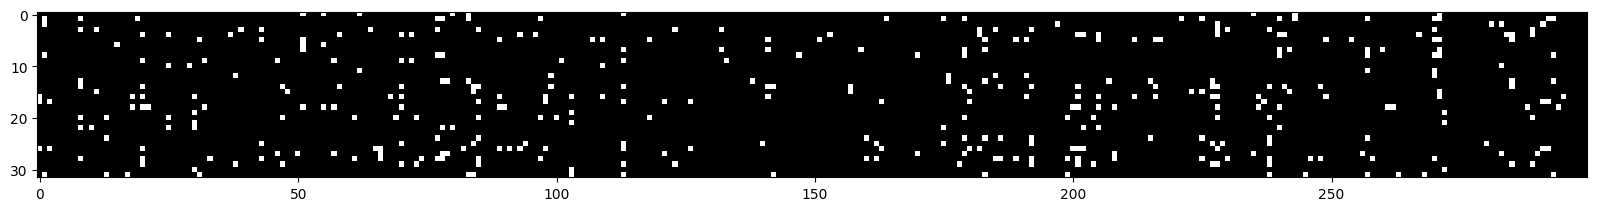

In [8]:
#Building MLP and setting up the training loop
torch.manual_seed(2147483647)

num_iterations = 15000
learning_rate = 0.01
n_hidden1 = 300
n_hidden2 = 27
n_embedding = 10
block_size = 3


C=torch.randn((27,n_embedding), requires_grad=True)
emb = C[Xtr]
x = emb.view(-1, n_embedding * block_size)


W1=torch.randn(n_embedding * block_size, n_hidden1) * 0.2
W1.requires_grad = True
b1=torch.randn(n_hidden1) * 0.02
b1.requires_grad = True


W2 = torch.randn(n_hidden1, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)
    h_b = torch.tanh(x @ W1 + b1)
    logits = h_b @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

#Evaluating trained model on validation data - compare with final training loss

#Forward Pass on validation data
emb = C[Xval]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(f"\nValidation Loss:",mean_neg_log.item())


#Forward Pass on training data - final training loss
emb = C[Xtr]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(f"\nFinal Training Loss:",mean_neg_log.item())

plt.figure(figsize=(20,10))
plt.imshow(h_b.abs() > 0.99, cmap='grey', interpolation='nearest')



Notice above that we scaled W1 by 0.2, but why ? Why wasn't 0.1 chosen rather than 0.2 ? Is there a way to choose a more 'suitable' value? When we scale W1, as much as possible, we want to ensure the pre-activations roughly perserve the guassian distribution (Mean = 0, Std Deviation = 1). Why ?

Lets first remember, large pre-activations (magnitude) mean tan(h)=+-1. This is an issue because its gradient is 0, hence saturated tanh issue we described above. This is why we were scaling in the first place

What if the std deviation of the pre-activations is large ? -> This will result in large magnitude pre-activations, which causes tanh saturation issue. This issue gets more compounded as the number of layers increase. Variance compounds multiplicatively across layers, so if each layer has std deviation = 5, by layer 10, its 5^10 (9765625), meaning tanh=+-1 and all tanhs are saturated.

What if the std deviation of the pre-activation is very small ? -> This means the output of the neuron will be very similar regardless of the input. This is also an issue. Lets say input 1 = Max and input 2 = Tom, if they both have outputs = 0.002 from the neuron, how will the network learn to differentiate between them ? This issue also get more compounded as the number of layers increases. For the same reason mentioned above.

This is why std deviation = 1 is important

Now, what should we scale the Weights by to maintain the pre-activations gaussian distribution ? Without getting into the details of the math, the weights should be scaled by z = (5/3) / sqrt(fan_in) where fan_in = number of inputs into the layer.

Hence, we should scaled W1 by z = (5/3) / sqrt (30)



(0, 3.3120551109313965)
(1, 3.200497627258301)
(2, 3.2100768089294434)
(3, 3.141263484954834)
(4, 3.1261987686157227)
(5, 3.06947660446167)
(6, 2.898928165435791)
(7, 3.1385040283203125)
(8, 2.872084379196167)
(9, 2.910642147064209)
(10, 2.7974162101745605)
(11, 2.716495990753174)
(12, 2.58888578414917)
(13, 2.844688892364502)
(14, 2.6643152236938477)
(15, 3.0093328952789307)
(16, 2.7705368995666504)
(17, 2.8350906372070312)
(18, 2.611740827560425)
(19, 2.7693240642547607)
(20, 2.9822306632995605)
(21, 2.8448851108551025)
(22, 2.696621894836426)
(23, 2.7129971981048584)
(24, 2.5439229011535645)
(25, 2.8621206283569336)
(26, 2.6357333660125732)
(27, 2.6732776165008545)
(28, 2.9927937984466553)
(29, 3.0753440856933594)
(30, 2.801011562347412)
(31, 2.604733943939209)
(32, 3.0113675594329834)
(33, 2.575407028198242)
(34, 2.7144620418548584)
(35, 2.864598274230957)
(36, 2.8590445518493652)
(37, 2.7064085006713867)
(38, 2.6843910217285156)
(39, 2.7476048469543457)
(40, 2.7097179889678955)
(4

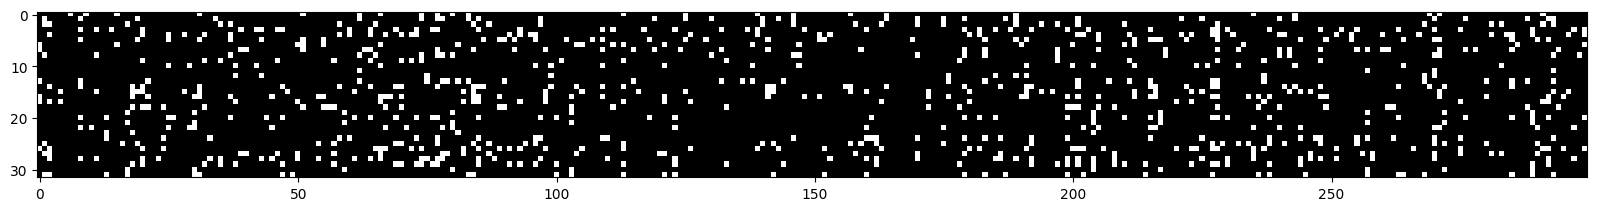

In [9]:
#Building MLP and setting up the training loop
torch.manual_seed(2147483647)

num_iterations = 15000
learning_rate = 0.01
n_hidden1 = 300
n_hidden2 = 27
n_embedding = 10
block_size = 3


C=torch.randn((27,n_embedding), requires_grad=True)
emb = C[Xtr]
x = emb.view(-1, n_embedding * block_size)


W1=torch.randn(n_embedding * block_size, n_hidden1) * ((5/3)/(n_embedding * block_size)**0.5)
W1.requires_grad = True
b1=torch.randn(n_hidden1) * 0.02
b1.requires_grad = True


W2 = torch.randn(n_hidden1, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)
    h_b = torch.tanh(x @ W1 + b1)
    logits = h_b @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

#Evaluating trained model on validation data - compare with final training loss

#Forward Pass on validation data
emb = C[Xval]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(f"\nValidation Loss:",mean_neg_log.item())


#Forward Pass on training data - final training loss
emb = C[Xtr]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(f"\nFinal Training Loss:",mean_neg_log.item())

plt.figure(figsize=(20,10))
plt.imshow(h_b.abs() > 0.99, cmap='grey', interpolation='nearest')



Previously, what we did was that we attempted to scale W1 such that the pre-activation would be approximately a guassian distribution.Some google researchers wrote a paper 'Batch Normalization', their main claim was: If we want the pre-activation to be a guassian distribution, we dont we just normalizate the pre-activations directly?

So, instead of only scaling W1, we will first find the mean and std-deviation of the pre-activations. Then, we will apply the following formula: (pre-activation - mean)/std deviation. This will result in a mean of 0 and std deviation of 1

(0, 3.3134379386901855)
(1, 3.2613332271575928)
(2, 3.2603189945220947)
(3, 3.2539689540863037)
(4, 3.183138608932495)
(5, 3.1382269859313965)
(6, 3.0271010398864746)
(7, 3.2511813640594482)
(8, 3.032402992248535)
(9, 3.071451187133789)
(10, 2.9324729442596436)
(11, 2.9483604431152344)
(12, 2.7970468997955322)
(13, 3.0999929904937744)
(14, 2.799832820892334)
(15, 3.107804298400879)
(16, 2.930269956588745)
(17, 2.934833526611328)
(18, 2.766464948654175)
(19, 3.029437780380249)
(20, 3.1298556327819824)
(21, 2.956183671951294)
(22, 2.9117844104766846)
(23, 2.816115617752075)
(24, 2.5945959091186523)
(25, 2.8212571144104004)
(26, 2.7587485313415527)
(27, 2.8640506267547607)
(28, 3.1663427352905273)
(29, 3.250223398208618)
(30, 2.9610583782196045)
(31, 2.8132705688476562)
(32, 3.0689117908477783)
(33, 2.706620454788208)
(34, 2.7467164993286133)
(35, 2.9146833419799805)
(36, 2.892848014831543)
(37, 2.8717312812805176)
(38, 2.7147128582000732)
(39, 2.968545436859131)
(40, 2.8692944049835205)


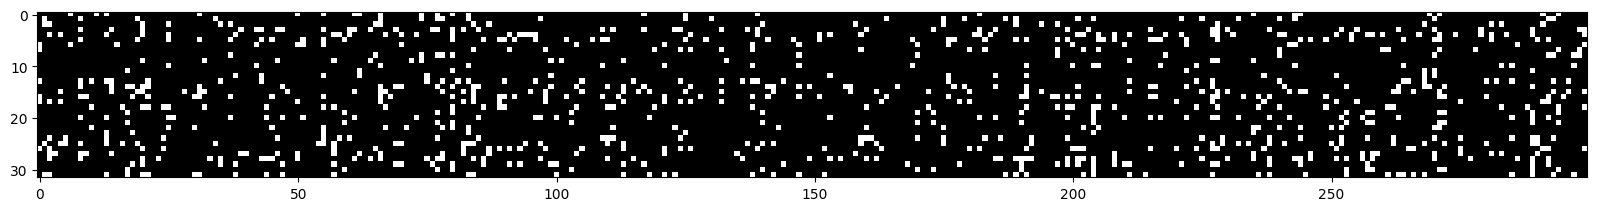

In [10]:
#Building MLP and setting up the training loop
torch.manual_seed(2147483647)

num_iterations = 15000
learning_rate = 0.01
n_hidden1 = 300
n_hidden2 = 27
n_embedding = 10
block_size = 3


C=torch.randn((27,n_embedding), requires_grad=True)
emb = C[Xtr]
x = emb.view(-1, n_embedding * block_size)


W1=torch.randn(n_embedding * block_size, n_hidden1) * ((5/3)/(n_embedding * block_size)**0.5)
W1.requires_grad = True
b1=torch.randn(n_hidden1) * 0.02
b1.requires_grad = True


W2 = torch.randn(n_hidden1, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)
    hpreact = x @ W1 + b1
    hpreact = hpreact - hpreact.mean(0, keepdim=True)/hpreact.std(0, keepdim=True)
    h_b = torch.tanh(hpreact)
    logits = h_b @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

#Evaluating trained model on validation data - compare with final training loss

#Forward Pass on validation data
emb = C[Xval]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(f"\nValidation Loss:",mean_neg_log.item())


#Forward Pass on training data - final training loss
emb = C[Xtr]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(f"\nFinal Training Loss:",mean_neg_log.item())

plt.figure(figsize=(20,10))
plt.imshow(h_b.abs() > 0.99, cmap='grey', interpolation='nearest')

Notice that we didn't get better results, why ? We are forcing every batch to be exactly a Gaussian Distribution. Although unit gaussian is a good starting point, its most certainly not the most optimal distribution for solving the task. Maybe the network would perform better if some neurons where most saturated and others less saturated, maybe some neurons should have a shifted mean. By hard clamping the pre-activation to mean 0 and std 1 at every iteration we've stolen some degree of freedom from the optimizer.

What should we do ? -> We add a learnab which allows the model to learn the optimal distribution. At initialization, γ=1 and β=0 (unit gaussian).

Whats the point of this ? Why dont we just initialize unit gaussian (like before) and then proceed with training normally ? Lets assume the network is very deep (50-100 layers), than initialization at unit gaussian no longer has a very big impact once youve reached a deep layer. Thats why at every pre-activation, we normalize back to unit gaussian, but give the model a learnable gain and bias, allowing the pre-activations to be more grounded.

Hence hpreact = gain * ((hpreact - hpreact_mean)/hpreact_std) + bias

(0, 3.310184955596924)
(1, 3.268503427505493)
(2, 3.2624340057373047)
(3, 3.2656404972076416)
(4, 3.201368808746338)
(5, 3.1505918502807617)
(6, 3.078888177871704)
(7, 3.2112507820129395)
(8, 3.076024055480957)
(9, 3.108935832977295)
(10, 2.9658358097076416)
(11, 3.016967535018921)
(12, 2.870859146118164)
(13, 3.1493072509765625)
(14, 2.8243870735168457)
(15, 3.1466586589813232)
(16, 2.9448647499084473)
(17, 2.9831597805023193)
(18, 2.838513135910034)
(19, 3.0855355262756348)
(20, 3.1533806324005127)
(21, 2.9803569316864014)
(22, 2.9579389095306396)
(23, 2.8653712272644043)
(24, 2.628145933151245)
(25, 2.781148672103882)
(26, 2.8129873275756836)
(27, 2.92057728767395)
(28, 3.190358877182007)
(29, 3.2503726482391357)
(30, 2.996338367462158)
(31, 2.889538049697876)
(32, 3.0531811714172363)
(33, 2.8084139823913574)
(34, 2.774435520172119)
(35, 2.989158868789673)
(36, 2.966183662414551)
(37, 2.9476006031036377)
(38, 2.7376866340637207)
(39, 2.9431867599487305)
(40, 2.979646921157837)
(41, 

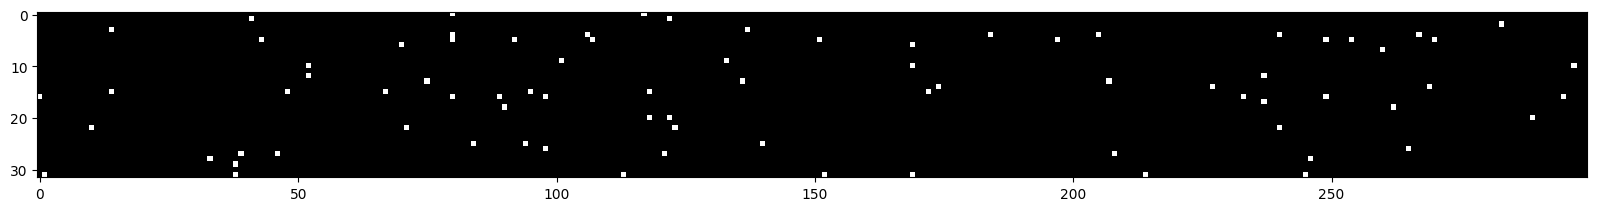

In [11]:
#Building MLP and setting up the training loop
torch.manual_seed(2147483647)

num_iterations = 15000
learning_rate = 0.01
n_hidden1 = 300
n_hidden2 = 27
n_embedding = 10
block_size = 3


C=torch.randn((27,n_embedding), requires_grad=True)
emb = C[Xtr]
x = emb.view(-1, n_embedding * block_size)


W1=torch.randn(n_embedding * block_size, n_hidden1) * ((5/3)/(n_embedding * block_size)**0.5)
W1.requires_grad = True
b1=torch.randn(n_hidden1) * 0.02
b1.requires_grad = True


W2 = torch.randn(n_hidden1, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)

bngain = torch.ones((1,n_hidden1), requires_grad=True)
bnbias = torch.zeros((1,n_hidden1), requires_grad=True)

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)
    hpreact = x @ W1 + b1
    hpreact = (bngain * ((hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True))) + bnbias
    h_b = torch.tanh(hpreact)
    logits = h_b @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    bngain.data += learning_rate * -bngain.grad
    bnbias.data += learning_rate * -bnbias.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()
    bngain.grad.zero_()
    bnbias.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

#Evaluating trained model on validation data - compare with final training loss

#Forward Pass on validation data
emb = C[Xval]
x = emb.view(-1,n_embedding * block_size)
hpre_val = x @ W1 + b1
hpre_val = (bngain * ((hpre_val - hpre_val.mean(0, keepdim=True))/hpre_val.std(0, keepdim=True))) + bnbias
h=torch.tanh(hpre_val)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(f"\nValidation Loss:",mean_neg_log.item())


#Forward Pass on training data - final training loss
emb = C[Xtr]
x = emb.view(-1,n_embedding * block_size)
hpre_train = x @ W1 + b1
hpre_train = (bngain * ((hpre_train - hpre_train.mean(0, keepdim=True))/hpre_train.std(0, keepdim=True))) + bnbias
h=torch.tanh(hpre_train)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(f"\nFinal Training Loss:",mean_neg_log.item())

plt.figure(figsize=(20,10))
plt.imshow(h_b.abs() > 0.99, cmap='grey', interpolation='nearest')

There is one odd, but useful, side-effect that happens as a result of the batch normalization we introduced. Lets look at the below examples to understand it better:

Assume the input to the neural net is 'emma', previously when we wanted to do a forward pass we would do the following:

pre-activation = x_emma @ W1 + b1

h_b = torch.tanh(pre-activation)

logits = h_b @ W2 + b2

Hence, the pre-activation and the logits depend on two things: The input (emma) and the network parameters


However, after adding the batch normalisation, when we fo the forward pass we would do the following:

hpreact = x_emma @ W1 + b1

hpreact = (bngain * ((hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True))) + bnbias

h_b = torch.tanh(hpreact)

logits = h_b @ W2 + b2


Hence, the pre-activation and the logits now depend on three things: The input (emma), the network parameters, and the other 31 examples in the batch (through bngain and bnbias)




So what does this mean ?

Previously, assuming network parameters are constant, the input (emma) will always produce the same logit. However, now it also depends on the 31 examples with it in the batch. Say 'emma' went through the network with batch A (31 other examples) it would produce a specific logit Y. If it goes through the network again with another batch B (31 other examples), it would produce another logit Z. Although this seems a bit odd, it is in fact a desirable side-effect. Thats because it creates a sort of 'noise injection', rather than the network latching on to a specific mapping for the 'emma' example, its forced to be robust to small perterubations.

There is one issue that arises also as a result of the batch normalization. Now, lets assume we have completed model training and want to see the probability of a specific word (emma). We'd have to conduct a forward pass through the neural net on only the input emma, so:

hpre_val = x_emma @ W1 + b1
hpre_val = (bngain * ((hpre_val - hpre_val.mean(0, keepdim=True))/hpre_val.std(0, keepdim=True))) + bnbias
h=torch.tanh(hpre_val)

Remember that x_emma, is now only 1 example (not a batch of 32), so the hpre_val-hpre_val.mean = 0. In addition, hpre_val.std is undefined since its only 1 example. Hence, this whole formula no longer works. μ and σ are fully dependent on the input, this is what causes the issues. Hence, we need a μ and σ which are not recomputed from the current input, we need 'fixed constants'. Hence, we introduce running averages: the typical mean and std the pre-activations had across the training data. To do that we introduce the following formula:

bnmean_running = 0.999 * bnmean_running + 0.001 * mu
bnstd_running  = 0.999 * bnstd_running  + 0.001 * sigma

Every training batch contributes a small amount to the running bnmean and bnstd such that at the end of training the bnmean_running and bnstd_running estimate the typical μ and σ across the whole dataset






(0, 3.310184955596924)
(1, 3.268503427505493)
(2, 3.2624340057373047)
(3, 3.2656404972076416)
(4, 3.201368808746338)
(5, 3.1505918502807617)
(6, 3.078888177871704)
(7, 3.2112507820129395)
(8, 3.076024055480957)
(9, 3.108935832977295)
(10, 2.9658358097076416)
(11, 3.016967535018921)
(12, 2.870859146118164)
(13, 3.1493072509765625)
(14, 2.8243870735168457)
(15, 3.1466586589813232)
(16, 2.9448647499084473)
(17, 2.9831597805023193)
(18, 2.838513135910034)
(19, 3.0855355262756348)
(20, 3.1533806324005127)
(21, 2.9803569316864014)
(22, 2.9579389095306396)
(23, 2.8653712272644043)
(24, 2.628145933151245)
(25, 2.781148672103882)
(26, 2.8129873275756836)
(27, 2.92057728767395)
(28, 3.190358877182007)
(29, 3.2503726482391357)
(30, 2.996338367462158)
(31, 2.889538049697876)
(32, 3.0531811714172363)
(33, 2.8084139823913574)
(34, 2.774435520172119)
(35, 2.989158868789673)
(36, 2.966183662414551)
(37, 2.9476006031036377)
(38, 2.7376866340637207)
(39, 2.9431867599487305)
(40, 2.979646921157837)
(41, 

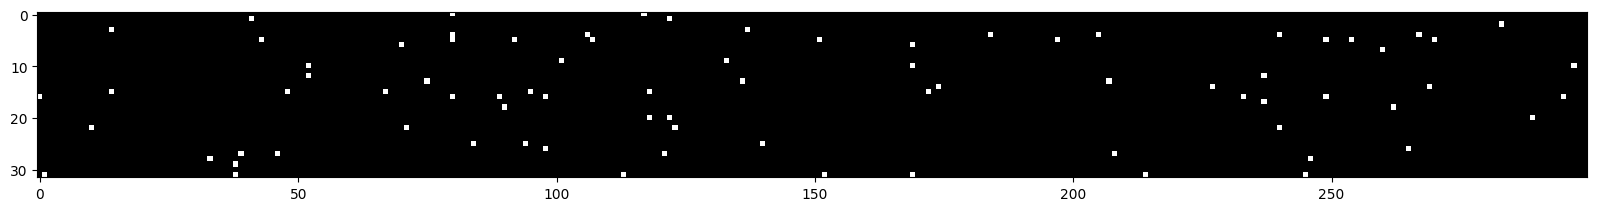

In [12]:
#Building MLP and setting up the training loop
torch.manual_seed(2147483647)

num_iterations = 15000
learning_rate = 0.01
n_hidden1 = 300
n_hidden2 = 27
n_embedding = 10
block_size = 3


C=torch.randn((27,n_embedding), requires_grad=True)
emb = C[Xtr]
x = emb.view(-1, n_embedding * block_size)


W1=torch.randn(n_embedding * block_size, n_hidden1) * ((5/3)/(n_embedding * block_size)**0.5)
W1.requires_grad = True
b1=torch.randn(n_hidden1) * 0.02
b1.requires_grad = True


W2 = torch.randn(n_hidden1, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)

bngain = torch.ones((1,n_hidden1), requires_grad=True)
bnbias = torch.zeros((1,n_hidden1), requires_grad=True)

bnmean_running = torch.zeros((1,n_hidden1))
bnstd_running = torch.ones((1,n_hidden1))

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)
    hpreact = x @ W1 + b1

    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = (bngain * ((hpreact - bnmeani)/bnstdi)) + bnbias

    with torch.no_grad():

        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi



    h_b = torch.tanh(hpreact)
    logits = h_b @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    bngain.data += learning_rate * -bngain.grad
    bnbias.data += learning_rate * -bnbias.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()
    bngain.grad.zero_()
    bnbias.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

#Evaluating trained model on validation data - compare with final training loss

#Forward Pass on validation data
emb = C[Xval]
x = emb.view(-1,n_embedding * block_size)
hpre_val = x @ W1 + b1
hpre_val = (bngain * ((hpre_val - bnmean_running)/bnstd_running)) + bnbias
h=torch.tanh(hpre_val)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(f"\nValidation Loss:",mean_neg_log.item())


#Forward Pass on training data - final training loss
emb = C[Xtr]
x = emb.view(-1,n_embedding * block_size)
hpre_train = x @ W1 + b1
hpre_train = (bngain * ((hpre_train - bnmean_running)/bnstd_running)) + bnbias
h=torch.tanh(hpre_train)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(f"\nFinal Training Loss:",mean_neg_log.item())

plt.figure(figsize=(20,10))
plt.imshow(h_b.abs() > 0.99, cmap='grey', interpolation='nearest')

Section 2: 'Pytorchfying the code' -> I will rewrite the code in such a way that more closely reflects how we'd see it in pytorch

In [62]:
import math

class linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g)/(fan_in **0.5)
        self.bias = torch.zeros(fan_out)

    def __call__(self, x):
        self.out = x @ self.weight + self.bias
        return self.out

    def parameters(self):
        return self.weight, self.bias

class BatchNorm1D:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True  #We add this to differentiate between training and inference (when in training mean and std are of that batch but in inference its the running average)

        self.mean_running = torch.zeros(dim)
        self.std_running = torch.ones(dim)
        self.gain = torch.ones(dim)
        self.bias = torch.zeros(dim)

    def __call__(self,x):
        #Forward pass of the batch normalization (up to final pre-activation) -> x is pre-activation
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xstd = x.std(0, keepdim=True)
        else:
            xmean = self.mean_running
            xstd = self.std_running

        xhat = (x-xmean)/xstd

        self.out = self.gain * xhat +self.bias

        if self.training:
            with torch.no_grad():

                self.mean_running = (1-self.momentum) * self.mean_running + (self.momentum) * xmean
                self.std_running = (1-self.momentum) * self.std_running + (self.momentum) * xstd

        return self.out


    def parameters(self):
        return self.gain, self.bias


class tanh:

    def __call__(self,x):
     self.out = torch.tanh(x)
     return self.out

    def parameters(self):
        return []




The foundational classes have been created, now the next step is to create the model architecture. We will assume 10-dimensional embeddings, 6 layers - 100 neurons, tanh activation function. Last layer maps out to 27 nodes (to represent the probability of each of the 27 letters)

In [56]:
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27, n_embd), generator=g)
layers = [
linear(n_embd * block_size, n_hidden), tanh(),
linear(n_hidden, n_hidden), tanh(),
linear(n_hidden, n_hidden), tanh(),
linear(n_hidden, n_hidden), tanh(),
linear(n_hidden, n_hidden), tanh(),
linear(n_hidden, 27),

]

with torch.no_grad():
    layers[-1].weight *= 0.1 #Make last layer less confident
    for layer in layers[:-1]:
      if isinstance(layer, linear):
        layer.weight *= 5/3 #Apply gain to all the other layers

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True


Now, lets create the training loop

In [57]:
iter = 200000
batch_size = 32
lossi = []
ud = []

for i in range(iter):

    #Construct the Minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)


    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)

    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Ytr[ix])

    #Backward Pass
    for layer in layers:
        layer.out.retain_grad()

    loss.backward()

    #Track stats (before gradient gets zeroed)
    with torch.no_grad():
        ud.append([((learning_rate*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    #Update
    learning_rate = 0.1 if i < 0.75 * iter else 0.01
    for p in parameters:
        p.data -= learning_rate * p.grad
        p.grad.zero_()

    #Track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{iter:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())

      0/ 200000: 3.2962
  10000/ 200000: 2.3341
  20000/ 200000: 2.0329
  30000/ 200000: 1.7317
  40000/ 200000: 2.1076
  50000/ 200000: 2.2375
  60000/ 200000: 1.8674
  70000/ 200000: 2.1207
  80000/ 200000: 2.4407
  90000/ 200000: 1.8475
 100000/ 200000: 2.3171
 110000/ 200000: 2.2799
 120000/ 200000: 2.1532
 130000/ 200000: 2.1984
 140000/ 200000: 1.6901
 150000/ 200000: 1.7187
 160000/ 200000: 1.8871
 170000/ 200000: 1.6912
 180000/ 200000: 2.1878
 190000/ 200000: 1.9292


Now lets look at some useful visualisations and decide where the model is behaving well

layer 1 (      tanh): mean -0.05, std 0.88, saturated: 54.06%
layer 3 (      tanh): mean -0.02, std 0.90, saturated: 59.47%
layer 5 (      tanh): mean -0.01, std 0.92, saturated: 61.91%
layer 7 (      tanh): mean -0.06, std 0.93, saturated: 63.66%
layer 9 (      tanh): mean +0.03, std 0.85, saturated: 38.75%
layer 1 (      tanh): mean +0.000025, std 3.398227e-03
layer 3 (      tanh): mean -0.000113, std 3.107072e-03
layer 5 (      tanh): mean -0.000001, std 3.139125e-03
layer 7 (      tanh): mean -0.000031, std 3.722218e-03
layer 9 (      tanh): mean -0.000105, std 4.625302e-03


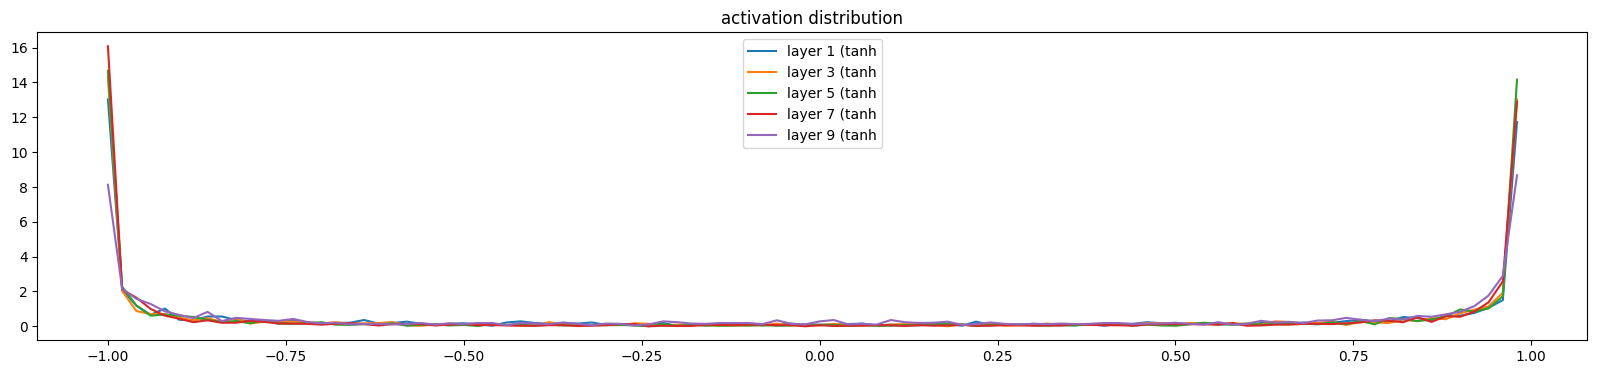

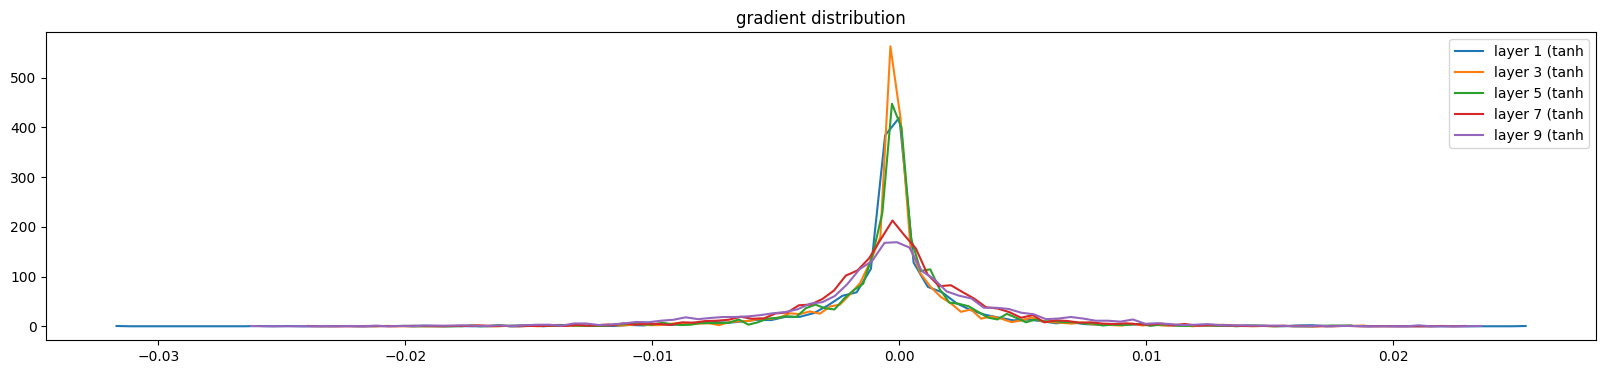

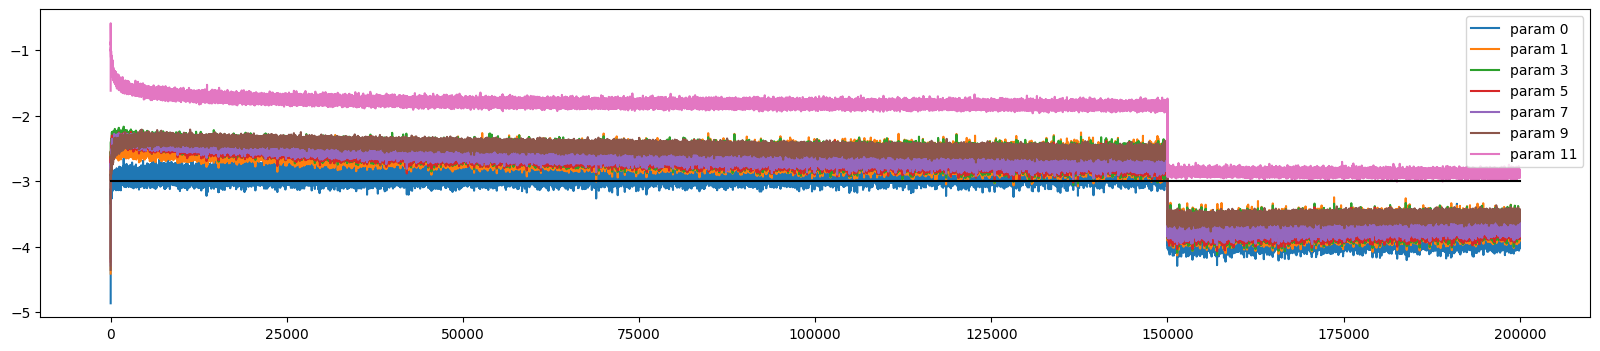

In [58]:
#Visualize the activations
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')


#Visualize the Gradients
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

#Visualize the update-data ratio
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

Graph 1: Activation Distribution

The graph looks fine, the tanh saturation is relatively low (30%) and consistent throughout the layers. In addition, the mean is approximately 0 with a healthy std deviation of approximately 0.82.

Graph 2: Gradient Distribution

The behaviour that is favourable is having approximately similar gradient distributions throughout all the layers. Lets think about how a gradient reaches an early layer (such as layer 1), its through backpropogation which applies the chain rule at every layer. So, the gradient at layer 1 is the gradient at the output multiplied through every layer in between. If we have something gradients which are extremely small/large this effect get compounded through.

Generally, the graph that we have is good, gradients are approximately the same. However at the deeper layers (7,9), the variance is slightly higher


Graph 3: Update - Data ratio
The behaviour that is favourable is the update-data ratio being around (1e-3), this suggests that each update is approximately 0.1% of the datas magnitude. This is enough to learn stably over time. If its too big it will cause huge jumps and be unstable, if its too small, it wont learn fast enough.

Our chart suggest relatively good behaviour. Most params are around 1e-3 although there are some which are slightly higher (close to 2.2). Notice there is one param which is higher (this is as a result of us artificially multiplying the last layer by 0.1). Also notice at approximately iteration 150,000 the update-data ratio suddenly jumps down for all params, this is due to the learning rate decay that we activate at (0.75 * iter = 150,000)

Now, we will introduce batch Normalization to the model and we will inspect how the behaviour is instantly good without us having to experiment with different scaling factors etc.

In [63]:
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27, n_embd), generator=g)
layers = [
linear(n_embd * block_size, n_hidden),BatchNorm1D(n_hidden),tanh(),
linear(n_hidden, n_hidden), BatchNorm1D(n_hidden),tanh(),
linear(n_hidden, n_hidden), BatchNorm1D(n_hidden),tanh(),
linear(n_hidden, n_hidden), BatchNorm1D(n_hidden),tanh(),
linear(n_hidden, n_hidden), BatchNorm1D(n_hidden),tanh(),
linear(n_hidden, 27), BatchNorm1D(27),

]

with torch.no_grad():
    layers[-1].gain *= 0.1 #Make last layer less confident
    for layer in layers[:-1]:
      if isinstance(layer, linear):
        layer.weight *= 5/3 #Apply gain to all the other layers

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

In [64]:
iter = 200000
batch_size = 32
lossi = []
ud = []

for i in range(iter):

    #Construct the Minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)


    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)

    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Ytr[ix])

    #Backward Pass
    for layer in layers:
        layer.out.retain_grad()

    loss.backward()

    #Track stats (before gradient gets zeroed)
    with torch.no_grad():
        ud.append([((learning_rate*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    #Update
    learning_rate = 0.1 if i < 0.75 * iter else 0.01
    for p in parameters:
        p.data -= learning_rate * p.grad
        p.grad.zero_()

    #Track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{iter:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())

      0/ 200000: 3.2870
  10000/ 200000: 2.3578
  20000/ 200000: 2.1042
  30000/ 200000: 1.9646
  40000/ 200000: 2.2144
  50000/ 200000: 2.2264
  60000/ 200000: 1.7339
  70000/ 200000: 2.1746
  80000/ 200000: 2.1895
  90000/ 200000: 1.8282
 100000/ 200000: 2.3641
 110000/ 200000: 2.2595
 120000/ 200000: 2.0967
 130000/ 200000: 1.8986
 140000/ 200000: 1.8310
 150000/ 200000: 1.9426
 160000/ 200000: 1.8674
 170000/ 200000: 1.8340
 180000/ 200000: 2.2498
 190000/ 200000: 2.0144


layer 2 (      tanh): mean -0.01, std 0.70, saturated: 16.31%
layer 5 (      tanh): mean -0.02, std 0.74, saturated: 19.16%
layer 8 (      tanh): mean -0.00, std 0.77, saturated: 19.06%
layer 11 (      tanh): mean +0.02, std 0.79, saturated: 20.84%
layer 14 (      tanh): mean -0.01, std 0.81, saturated: 23.09%
layer 2 (      tanh): mean +0.000000, std 3.181613e-03
layer 5 (      tanh): mean +0.000000, std 3.066453e-03
layer 8 (      tanh): mean +0.000000, std 3.129136e-03
layer 11 (      tanh): mean +0.000000, std 3.453022e-03
layer 14 (      tanh): mean +0.000000, std 3.800453e-03


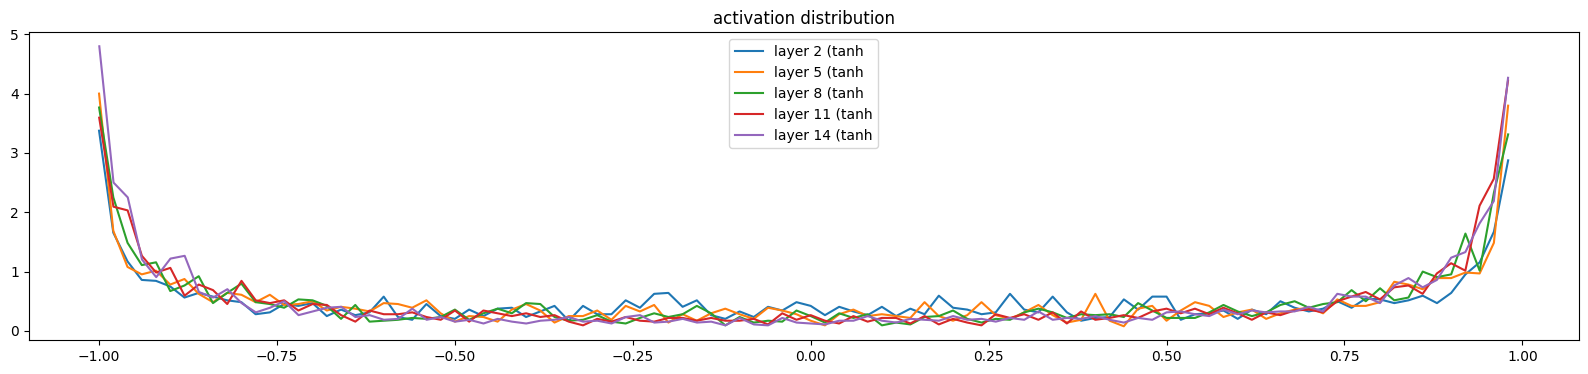

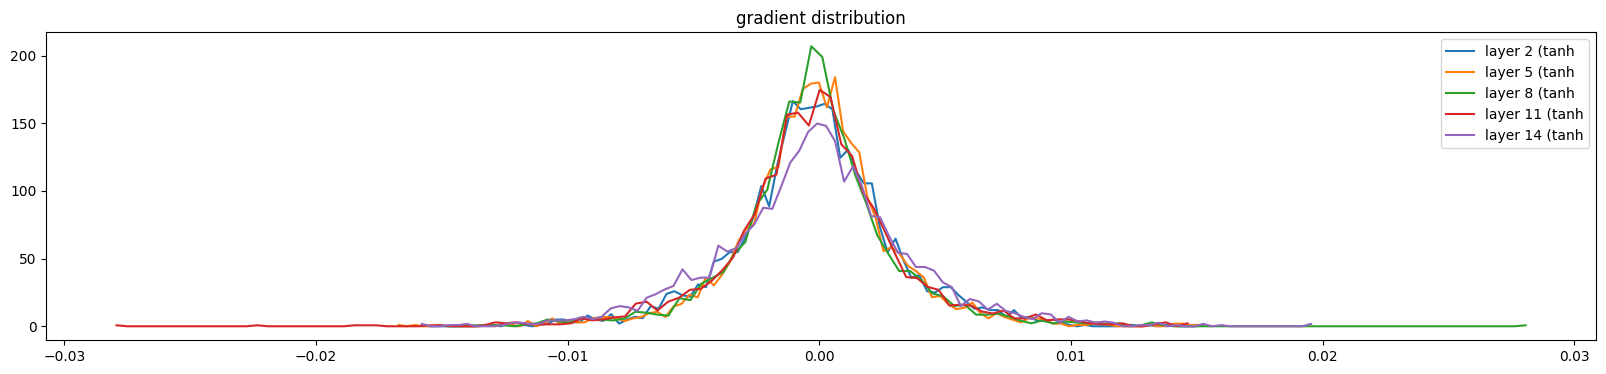

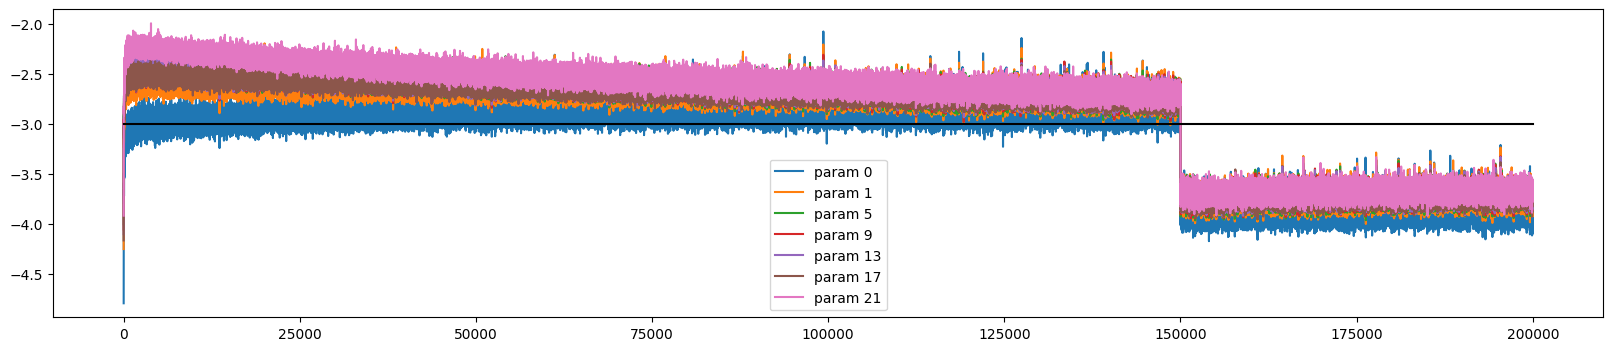

In [65]:
#Visualize the activations
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')


#Visualize the Gradients
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

#Visualize the update-data ratio
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);